Import modules, define network and apply transformations

In [2]:
import torch
from torchvision.datasets import Flowers102
import scipy
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()
        # Block 1
        self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)  
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.3)

        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        # Block 1
        x = self.activation_function(self.conv1_1(x))
        x = self.pool(self.activation_function(self.bn1(self.conv1_2(x))))

        # Block 2
        x = self.activation_function(self.conv2_1(x))
        x = self.pool(self.activation_function(self.bn2(self.conv2_2(x))))

        # Block 3
        x = self.activation_function(self.conv3_1(x))
        x = self.pool(self.activation_function(self.bn3(self.conv3_2(x))))

        # Block 4
        x = self.activation_function(self.conv4_1(x))
        x = self.pool(self.activation_function(self.bn4(self.conv4_2(x))))
        
        # Fully Connected Layers
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(self.activation_function(self.fc1(x)))
        x = self.fc2(x)
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
trainingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

testingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

flowersTrain = Flowers102(root = "./data", split = "train", download=True, transform = trainingTransform)
flowersValidate = Flowers102(root = "./data", split = "val", download=True, transform = testingTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = testingTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(flowersValidate, batch_size=batch_size, shuffle=False)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels


Initialise classifier, optimiser and loss function. Then train the model, output loss and evaluate accuracy per epoch.

Epoch 1, Validation Loss: 4.6050, Validation Accuracy: 0.0176
Epoch 1 - 4.599783316254616
Epoch 2, Validation Loss: 4.4111, Validation Accuracy: 0.0941
Epoch 2 - 4.478864103555679
Epoch 3, Validation Loss: 4.2581, Validation Accuracy: 0.1098
Epoch 3 - 4.376015618443489
Epoch 4, Validation Loss: 4.1691, Validation Accuracy: 0.0931
Epoch 4 - 4.283182263374329
Epoch 5, Validation Loss: 4.0555, Validation Accuracy: 0.1176
Epoch 5 - 4.171006329357624
Epoch 6, Validation Loss: 3.9696, Validation Accuracy: 0.1069
Epoch 6 - 4.064384408295155
Epoch 7, Validation Loss: 3.8435, Validation Accuracy: 0.1422
Epoch 7 - 3.969079479575157
Epoch 8, Validation Loss: 3.7551, Validation Accuracy: 0.1569
Epoch 8 - 3.8749658092856407
Epoch 9, Validation Loss: 3.7218, Validation Accuracy: 0.1863
Epoch 9 - 3.759034536778927
Epoch 10, Validation Loss: 3.6037, Validation Accuracy: 0.1667
Epoch 10 - 3.7121815159916878
Epoch 11, Validation Loss: 3.5592, Validation Accuracy: 0.1892
Epoch 11 - 3.6109872460365295
Epo

Text(0.5, 0, 'Epoch')

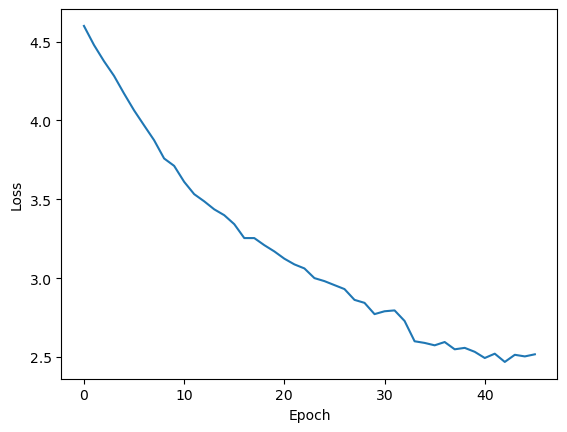

In [3]:
classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.relu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(classifier.parameters(), lr=0.0001, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=3)

epochs = 100
bestLoss = float('inf')
patience = 3 
lossTolerance = 1e-4
losses = []
for i in range(epochs):
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Epoch {i + 1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

  scheduler.step(val_loss)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch {i+1} - {epochLoss}")

  # Check for early stopping
  if epochLoss + lossTolerance < bestLoss:
      bestLoss = epochLoss
      patience = 3
  else:
      patience -= 1
      if patience == 0:
          print("Loss hasn't improved for the last few epochs. Stopping training.")
          break

# Plot graph
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

Calculate model accuracy

In [4]:
classifier.eval()

with torch.no_grad():
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)

        total += 1
        if predictedClass.item() == labels.item():
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.27630509025857863


Model's accuracy (on my run): 27.6% - still somewhat low, but definitely improving.
The 4 block CNN model is almost doubly as good as my 2 layer CNN model, indicating that adding more convolutional layers helped performance.
Unfortunately the model plateaus at around 30%, so investigation into how this can be remedied would be my next step.